# Basic demonstration of fUSi analysis

This notebook shows the basic demonstration of analyzing audio data collected at UCLA


In [22]:
%load_ext autoreload
%autoreload 2

import os
import re
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from IPython.display import HTML, Video
from anise.gui import *
import anise.motion_utils as motion_utils
import anise.utils as utils

import nibabel as nib
from sklearn.cluster import DBSCAN


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data from NIFTI

In [4]:
#################################################################
#      Define data paths and choose output path location        #
#################################################################

# If NIFTI has not been parsed in to fUSI_BIDS format, use the following line on terminal to parse data:
# ```python fUSI_to_BIDS_session.py /2024-06-13/UCLA_006/ --root /cassini/UCLA_collaboration```

base_path = Path.home() / 'Downloads/UCLA_fUSI_BIDS/sourcedata/sub-UCLA_006/ses-2024-06-13'

run = 6
    
run_folder = f'run-{run:02d}'

# Get the registration and GLM output directories
register_dir, glm_dir = utils.get_BIDS_derivative_dir(base_path)

# find filenames that match with the run
filenames = utils.get_run_files_from_BIDS(base_path, run_folder)
# for filename in filenames:
filename = filenames[0]
nifti_data, metadata, task_events = utils.load_data_from_BIDS(base_path, filename)
fusi_data = nifti_data.get_fdata()
filename = filename.replace('.nii.gz', '')
folder_tag = filename[re.search(run_folder, filename).start():-5]

reg_plot_dir = register_dir / 'plots' / folder_tag
reg_plot_dir.mkdir(parents=True, exist_ok=True)

task_events

Found 1 files:
	 sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_pwdt.nii.gz

Loaded NIFTI file: sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_pwdt.nii.gz
Loaded json: 	   sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_pwdt.json
Loaded events: 	   sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_events.tsv


,trial_type,onset,duration,time_stamp
0,tone_0110_Hz,18.047833,29.997999,2024-06-13 20:13:58.580883
1,tone_1760_Hz,75.584125,29.998015,2024-06-13 20:14:56.117175


In [8]:
# Define the list of params to be used in this analysis

log_neptune = False
run = {}
if log_neptune:
    import neptune
    run = neptune.init_run(
    project="forest-neurotech/auto-registration-glm",
    name=filename,
    )

# clustering parameters
param_c = dict(
    outlier_threshold = 500, # pwd intensity
    dim_red_method = 'VPCAGG', # 'PCA' or 'UMAP' or 'tSNE' or 'VGG'
    pca_n_components = min(100, fusi_data.shape[-1] - 1), # not applied for VGG
    perplexity = min(200, fusi_data.shape[-1] - 1), # specific for tSNE
    DBSCAN_eps = 1, # smaller eps, more clusters
    )

# registration parameters
param_reg = dict(
    use_thresholded_mask = False,
    auto_optimize_ref_frame = True,
    metric_name = 'mutual_information',        
    apply_image_registration = True,
    apply_temporal_smoothing = False,
    temporal_smoothing_window_size = 4, # Number of time points for smoothing
    crop_border = [0, 0, 0, 0], # crop the image to remove border
    )

# GLM parameters  
param_glm =  dict(
    apply_transform_in_design_mtx = True,
    smoothing_fwhm = .5, #0 spatial smoothing in mm to apply to the data before computing GLM
    behavior_offset = 0, # in seconds
    stat_threshold = 1,
    num_locations = 2, # How many ROIs to visualize. An additional random ROI will be added
    )

In [42]:
################################################
#           Display Power Doppler movie        #
################################################
# Video(register_dir / 'movies' /f'{filename}_before.mp4', embed=True)

Outlier frames more than 500.0 from median:  [18 21 22 23 24 25 27 28 29 30 32 33]


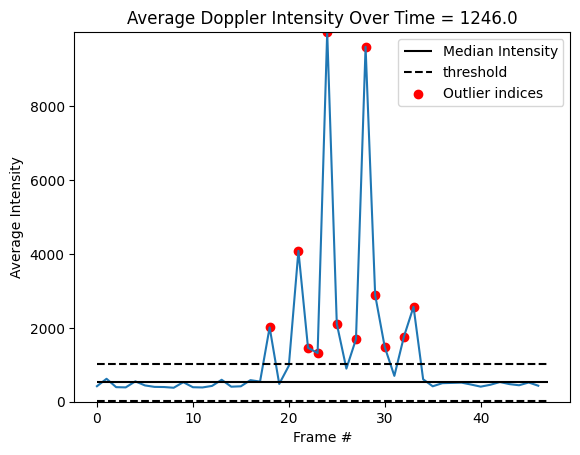

In [6]:
################################################
#     Display Doppler intensity time course    #
################################################

# find and confirm if there's any outlier frames that should be removed e.g. high brightness or noise
y_lim = []
doppler_intensity_per_frame, outlier_intensity_frames, fig, ax = \
    motion_utils.plot_pd_intensity_over_time(fusi_data, 
                                            y_lim=y_lim,
                                            outlier_threshold=param_c["outlier_threshold"])

fig.savefig(reg_plot_dir / 'doppler_intensity_over_time.png', dpi=300, bbox_inches='tight')    

# Discard out-of-plane images

Using PCA for clustering and visualization...
Applied binary masking to get thresholded images


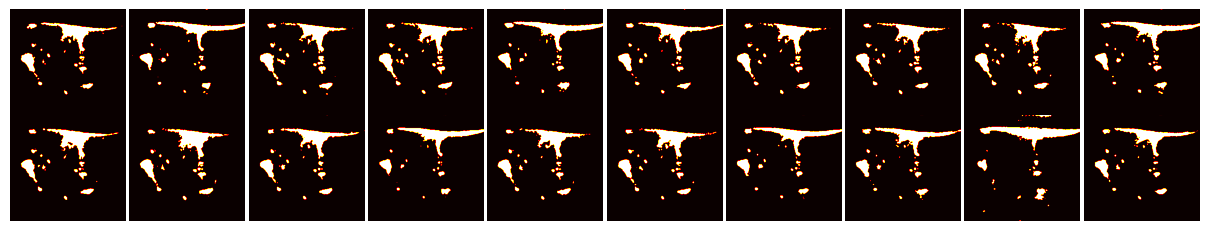

After PCA shape: (47, 46)
Explain variance sum of top 46 components:           100.0%


(<Figure size 400x300 with 1 Axes>, <Axes: title={'center': 'PCA projection'}>)

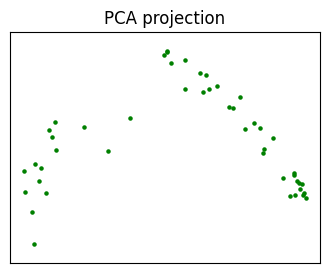

In [9]:
#############################################################################
#            If needed: identify  any out-of-plan images                    #
#############################################################################

dim_red_method = param_c["dim_red_method"] # 'VGG' or 'PCA' or 'UMAP' or 'tSNE'
pca_n_components = param_c["pca_n_components"]
# elevation
el = 0

print(f'Using {dim_red_method} for clustering and visualization...')

if dim_red_method == 'VGG':
    # Apply VGG to extract features, then PCA on the features
    from VGG_feature_extraction import VGG_PCA
    embedding = VGG_PCA(fusi_data, pca_n_components=2)
else:
    # use the thresholded images 
    threshold_imgs, density = motion_utils.get_threshold_image(fusi_data[:, el], threshold=0.5)
    print('Applied binary masking to get thresholded images')
    motion_utils.show_imgs(threshold_imgs, np.arange(20), fig_height=1.1, title='off')
    imgs_flatten = threshold_imgs.reshape(-1, threshold_imgs.shape[-1]).T
    # imgs_flatten = fusi_data.reshape(-1, fusi_data.shape[-1]).T

    from sklearn.decomposition import PCA
    pca=PCA(n_components=pca_n_components)

    # Reduce number of dimension
    lowd = pca.fit_transform(imgs_flatten)
    print(f'After PCA shape: {lowd.shape}')
    explained_variance = pca.explained_variance_ratio_
    print(f'Explain variance sum of top {pca_n_components} components: \
          {sum(explained_variance).round(3)*100}%')

    if dim_red_method == 'PCA':
        ### Visualize with PCA
        embedding = lowd[:,:2]
        
    elif dim_red_method == 'UMAP':
        import umap
        ### Visualize PCA projection with UMAP
        reducer = umap.UMAP(random_state=42, metric='cosine')
        embedding = reducer.fit_transform(lowd)

    elif dim_red_method == 'tSNE':
        from sklearn.manifold import TSNE
        ### Visualize PCA projection with tSNE
        tsne = TSNE(n_components=2, verbose=0, 
                    perplexity=param_c["perplexity"], max_iter=300, random_state=42)
        embedding = tsne.fit_transform(lowd)

# Visualize top 2 embedding space
motion_utils.plot_embedding(embedding, title=(dim_red_method + ' projection'))

## Use DBSCAN for clustering planes
DBSCAN (Density-Based Spatial Clustering of Applications with Noise): This algorithm excels at finding clusters of various shapes and identifying outliers. It focuses on data point density, grouping points close together in high-density regions and separating them from areas with lower density. 

DBSCAN only requires two parameters: 
- a distance threshold (`epsilon`) 
- a minimum number of points in a cluster (`min_samples`). 

It's robust to outliers and doesn't require pre-defining the number of clusters, making it a good choice for exploratory data analysis.

https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

In [10]:
def dbscan_clustering(embedding, starting_eps=1):
    # normalize the embedding
    embedding = embedding / np.std(embedding, axis=0)
    n_clusters = 5
    n_noise = embedding.shape[0]
    eps = starting_eps
    while n_clusters > 4 or n_noise > embedding.shape[0] / 2:
        print(f'Using DBSCAN with eps = {eps}\n')
        db = DBSCAN(eps=eps).fit(embedding)
        labels = db.labels_

        # Number of clusters in labels, ignoring noise if present.
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        print("Estimated number of clusters: %d" % n_clusters)
        print("Estimated number of noise points: %d" % n_noise)
        eps += 0.1
    return labels, n_clusters, n_noise, eps

eps = param_c["DBSCAN_eps"] # smaller eps, more clusters
labels, n_clusters, n_noise, eps = dbscan_clustering(embedding, starting_eps=eps)
param_c["DBSCAN_eps"] = eps

Using DBSCAN with eps = 1

Estimated number of clusters: 1
Estimated number of noise points: 0


## Relabel cluster number to match with our label convention
The output of kmean clusters are integers in ascending orders, and clusters are unassigned to the label class as described below. Hence, we are mapping kmean labels to match with our convention used in manual labeling.

**0** means in-plane, \
**-1** means out-of-plane and should be skipped, \
**i** (integer > 0) means new out-of-plane but should be included as new plane stacks.

outlier frames from feature extraction + clustering: []
outlier frames from power doppler intensity: [18 21 22 23 24 25 27 28 29 30 32 33]

Remapped predicted labels:
0 	 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0]
20 	 [ 0 -1 -1 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1  0  0  0  0  0  0]
40 	 [0 0 0 0 0 0 0]
% of out-of-plane frames: 25.53%


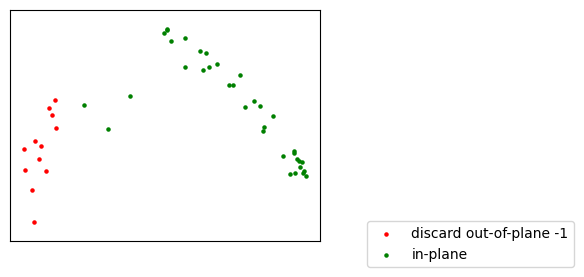

In [15]:
## Relabel cluster number to match with our label convention
pred_labels = motion_utils.remap_cluster_to_labels(labels)
pred_labels_oop_ind = np.where(pred_labels < 0)[0]
outliers_intensity_ind = np.where(outlier_intensity_frames)[0]
# combine with outlier_intensity_frames
pred_labels[outlier_intensity_frames] = -1
in_plane_indices = np.where(np.array(pred_labels) == 0)[0]

# logging the results
print(f'outlier frames from feature extraction + clustering: {pred_labels_oop_ind}')
print(f'outlier frames from power doppler intensity: {outliers_intensity_ind}')
# calculate overlap between outlier_intensity_frames and pred_labels
if not any(pred_labels_oop_ind) and not any(outliers_intensity_ind):
    overlap = len(set(pred_labels_oop_ind).intersection(outlier_intensity_frames))
    print('Percentage of overlap between the two types of outlier', \
        overlap/len(outlier_intensity_frames)*100 if len(outlier_intensity_frames) > 0 else \
        overlap/len(pred_labels_oop_ind)*100)
# print predicted labels 20 in a row
print('\nRemapped predicted labels:')
for row in range(len(pred_labels) // 20 + 1):
    print(row*20, '\t', pred_labels[row * 20:(row + 1) * 20])
print(f'% of in-plane frames: {len(in_plane_indices)/len(pred_labels)*100:.2f}%')

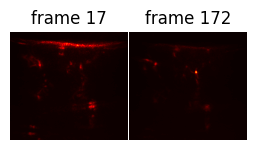

In [47]:
# show the outlier images, if any
if np.any(labels != 0):
    fig, axs = motion_utils.show_imgs(fusi_data[:,el], np.where(labels != 0)[0])
fig.savefig(reg_plot_dir / 'out_of_plane_images.png', dpi=300, bbox_inches='tight')

In [30]:
# Find nearest point to the centroid of the clusters
# Get the counts of consecutive labels
centroids, closest_points_in_plane = motion_utils.sort_in_plane_points_closest_to_centroid(
    embedding, pred_labels, n_clusters)
summary_count = motion_utils.get_consecutive_labels_counts(pred_labels)
labels_df = pd.DataFrame(summary_count.items(), columns=['label', 'consecutive counts'])
labels_df = labels_df.loc[labels_df['label'].values != -1.0]
labels_df['centroid'] = centroids.round(2).tolist()
labels_df


,label,consecutive counts,centroid
0,0.0,"[18, 2, 1, 1, 13]","[12.32, 2.65]"


# Perform image registration on in-plane frame indices

Reference frame for registration is: 32


100%|██████████| 35/35 [00:03<00:00,  9.39it/s]


Registered images shape: (274, 252, 35)
Done. Transformation was successfully performed.


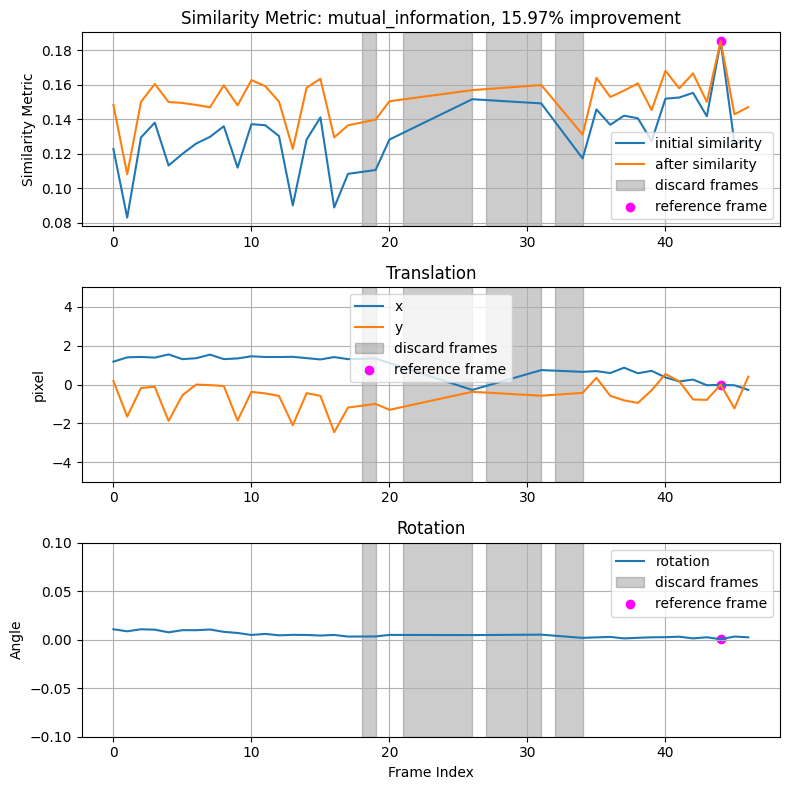

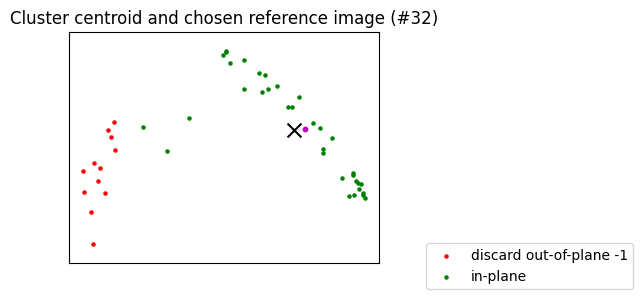

In [58]:

# Perform image registration on in-plane frame indices
if param_reg["apply_image_registration"]:
    registered_images, extra, final_ref_frame = motion_utils.auto_ants_registration_on_in_plane(
        fusi_data[:, el], in_plane_indices, closest_points_in_plane, 
        optimize_ref=param_reg["auto_optimize_ref_frame"])

    # plot registration transformation outputs
    fig, axs, prct_improve = motion_utils.plot_transform_params(extra, oop_labels=pred_labels, 
                                    metric_name=param_reg["metric_name"], 
                                    annotate_ref_frame=final_ref_frame)
    fig.savefig(reg_plot_dir / 'transform_params.png', dpi=400, bbox_inches='tight')

    # label the nearest point to the in-plane centroid in the embedding space
    fig, ax = motion_utils.plot_embedding(embedding, pred_labels, centroids=centroids, 
                           title=f'Cluster centroid and chosen reference image (#{final_ref_frame})')
    loc = in_plane_indices[final_ref_frame]
    ax.scatter(embedding[loc, 0], embedding[loc, 1], s=10, c='m')

else:
    registered_images = None
    final_ref_frame = None
    extra = pd.DataFrame({'in_plane_indices': in_plane_indices})
    fig, ax = motion_utils.plot_embedding(embedding, pred_labels, centroids=centroids, 
                           title=f'Clusters and centroids')

fig.savefig(reg_plot_dir / 'embedding_clusters.png', dpi=300, bbox_inches='tight')       


# Save registration outputs

In [52]:
# save outputs as csv
tsv_filename = register_dir / "fus" / (filename[:-4]+'outputs.tsv')
extra.to_csv(tsv_filename, index=False, sep='\t')

In [103]:
# save the registered images to a gif or a mp4
if param_reg["apply_image_registration"]:
    ani = MakeAnimation(registered_images, 
                        output_file=str(register_dir / 'movies' / f'{filename}_after.gif'), 
                        fps=10, 
                        depth=metadata['Depth'], 
                        lateral=metadata['Lateral'], 
                        time=metadata['VolumeTiming'],
                        )
    ani = MakeAnimation(registered_images, 
                        output_file=str(register_dir / 'movies' / f'{filename}_after.mp4'), 
                        fps=10, 
                        depth=metadata['Depth'], 
                        lateral=metadata['Lateral'], 
                        time=metadata['VolumeTiming'],
                        )
else:
    ani = None
HTML(ani.to_jshtml())

In [54]:
# crop the border of the registered images
if any(param_reg["crop_border"]) and registered_images is not None:
    registered_images = motion_utils.crop_images(registered_images, crop_border=param_reg["crop_border"])

In [59]:
N=2 # duplicate the data along the elevation dimension
# save the registered images to nifti
if param_reg["apply_image_registration"]:
    reg_pwd = np.tile(np.expand_dims(registered_images, 1), (1, N, 1, 1))
    if param_reg["apply_temporal_smoothing"]:
        pd = utils.boxcar_smooth(reg_pwd, param_reg["temporal_smoothing_window_size"])
        filename_new = utils.save_nifti_to_BIDS(register_dir / "fus", pd, 
                                             filename=filename, 
                                             filename_tag='register_smooth')
    else:
        filename_new = utils.save_nifti_to_BIDS(register_dir / "fus", reg_pwd, 
                                             filename=filename, 
                                             filename_tag='register')
else:
    data_selected = fusi_data[:, :, :, in_plane_indices]
    if param_reg["apply_temporal_smoothing"]:
        pd = utils.boxcar_smooth(data_selected, param_reg["temporal_smoothing_window_size"])
        filename_new = utils.save_nifti_to_BIDS(register_dir / "fus", pd,
                                             filename=filename, 
                                             filename_tag='in_plane_no_reg_smooth')
    else:
        filename_new = utils.save_nifti_to_BIDS(register_dir / "fus", data_selected,
                                             filename=filename, 
                                             filename_tag='in_plane_no_reg')

nifti_full_path = register_dir / "fus" / f'{filename_new}.nii.gz'

# load in nifti format
nifti_data = nib.load(nifti_full_path)
print(f'Loaded nifti data from {nifti_full_path}')
print(f'Nifti data shape: {nifti_data.shape}')

Output location: /Users/ewina/Downloads/UCLA_fUSI_BIDS/derivatives/registration/sub-UCLA_006/ses-2024-06-13/fus
Saved PD NIFTI file as: sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_pwdt_register.nii.gz
Loaded nifti data from /Users/ewina/Downloads/UCLA_fUSI_BIDS/derivatives/registration/sub-UCLA_006/ses-2024-06-13/fus/sub-UCLA_006_task-audio_tone_run-06_acq-0_proc-pca_60_pwdt_register.nii.gz
Nifti data shape: (274, 2, 252, 35)


In [88]:
nifti_full_path = register_dir / "fus" / f'{filename}_register.nii.gz'
if nifti_full_path.exists():
    # load in nifti format
    nifti_data = nib.load(nifti_full_path)
    print(f'Loaded nifti data from {nifti_full_path}')
    print(f'Nifti data shape: {nifti_data.shape}')
    extra = pd.read_csv(register_dir / "fus" / (filename[:-4]+'outputs.csv'))
    in_plane_indices = extra['in_plane_indices'].values
    print('Loaded translation and clustering outputs from csv')

Loaded nifti data from /Users/ewina/Downloads/UCLA_fUSI_BIDS/derivatives/registration/sub-UCLA_006/ses-2024-06-13/fus/sub-UCLA_006_task-audio_speech_run-04_acq-0_proc-pca_60_pwdt_register.nii.gz
Nifti data shape: (274, 2, 252, 217)
Loaded translation and clustering outputs from csv


# Perform first level GLM analsysis

In [97]:
# import nilearn as nl
from nilearn import image, plotting
from nilearn.glm.first_level import make_first_level_design_matrix, FirstLevelModel
from nilearn.plotting import plot_design_matrix
from nilearn.image import concat_imgs, mean_img, resample_img
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table
from sklearn.metrics import r2_score
from anise.process.fusi_glm_fit import get_ROI_activation

# initialize the GLM directory
zmap_dir = glm_dir / 'zmaps' / folder_tag
zmap_dir.mkdir(parents=True, exist_ok=True)
glm_plot_dir = glm_dir / 'plots' / folder_tag
glm_plot_dir.mkdir(parents=True, exist_ok=True)
print(f'GLM zmap directory: {zmap_dir}')
print(f'GLM plot directory: {glm_plot_dir}')


GLM zmap directory: /Users/ewina/Downloads/UCLA_fUSI_BIDS/derivatives/glm/sub-UCLA_006/ses-2024-06-13/zmaps/run-04_acq-0_proc-pca_60
GLM plot directory: /Users/ewina/Downloads/UCLA_fUSI_BIDS/derivatives/glm/sub-UCLA_006/ses-2024-06-13/plots/run-04_acq-0_proc-pca_60


/Users/ewina/miniforge3/envs/Mangrove/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:167: UserWarning:

The following unexpected columns in events data will be ignored: time_stamp



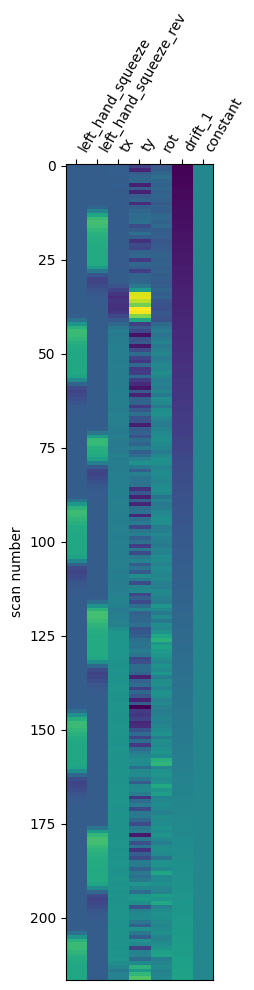

In [90]:
#######################################
#     Create design matrix for GLM    #
#######################################

hrf_model = "glover"

# Sub-period of time points that are in-plane
time_stamp = np.array(metadata['VolumeTiming'])[in_plane_indices]

if param_glm["apply_transform_in_design_mtx"]:
    design_matrix_name = 'yes_transform_design_mtx'
    design_matrix = make_first_level_design_matrix(
        time_stamp,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=extra[["translation_x", "translation_y", "rotation"]].to_numpy(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix_name = 'no_transform_design_mtx'
    design_matrix = make_first_level_design_matrix(
        time_stamp,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

ax = plot_design_matrix(design_matrix)
fig = ax.get_figure()
fig.savefig(glm_plot_dir / f'{design_matrix_name}.png', dpi=300, bbox_inches='tight')

In [91]:
# This cell creates an identity matrix of size equal to the number of columns in the design_matrix.
# It then constructs a dictionary named 'basic_contrasts' where each key is a column name from the design_matrix
# and the corresponding value is a row from the identity matrix. This effectively sets up basic contrasts
# for each experimental condition represented in the design_matrix.

contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
print('Basic contrasts:')
for key in basic_contrasts.keys():
    print(f'{key:15}: {basic_contrasts[key]}')

Basic contrasts:
left_hand_squeeze: [1. 0. 0. 0. 0. 0. 0.]
left_hand_squeeze_rev: [0. 1. 0. 0. 0. 0. 0.]
tx             : [0. 0. 1. 0. 0. 0. 0.]
ty             : [0. 0. 0. 1. 0. 0. 0.]
rot            : [0. 0. 0. 0. 1. 0. 0.]
drift_1        : [0. 0. 0. 0. 0. 1. 0.]
constant       : [0. 0. 0. 0. 0. 0. 1.]


In [92]:
# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,
                            mask_img=False,
                            smoothing_fwhm=param_glm["smoothing_fwhm"],
                            standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


# Perform first level GLM analsysis

In [93]:
print("Computing contrasts")
mean_image = mean_img(nifti_data)

# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
    # Save z_map in .mat format in the base_path folder
    z_map.to_filename(zmap_dir /f'{contrast_id}.nii.gz')
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.5 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
            z_map,
            bg_img=mean_image,
            threshold=2.58,        
            cut_coords=[0],
            display_mode="y",        
            black_bg=True,        
            title=contrast_id,
            output_file=zmap_dir / f'{contrast_id}.png',
            )
    plotting.show()

Computing contrasts
	contrast id: left_hand_squeeze
	contrast id: left_hand_squeeze_rev
	contrast id: tx
	contrast id: ty
	contrast id: rot
	contrast id: drift_1
	contrast id: constant


# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



Processing contrast: left_hand_squeeze
Processing contrast: left_hand_squeeze_rev


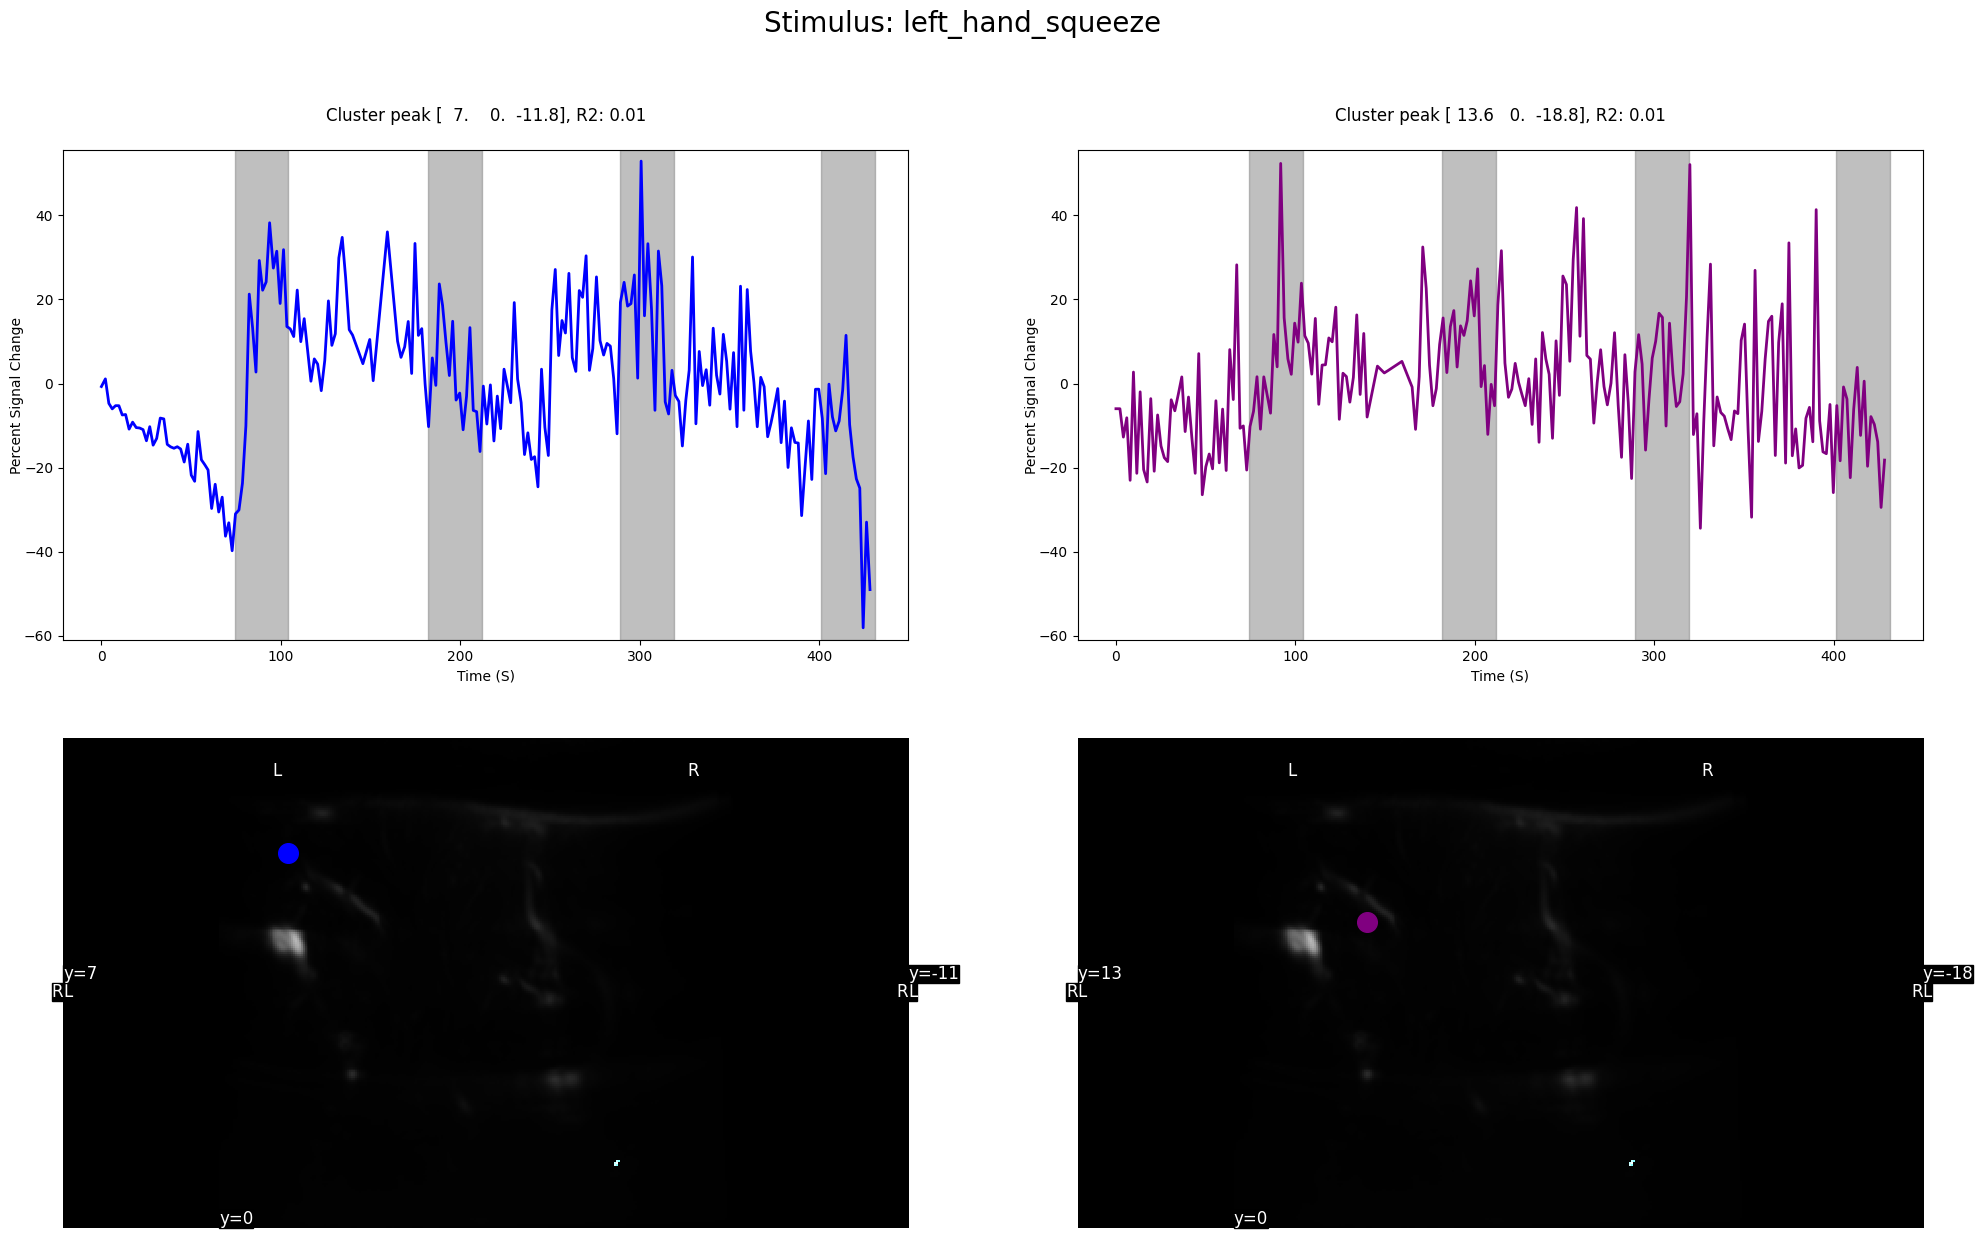

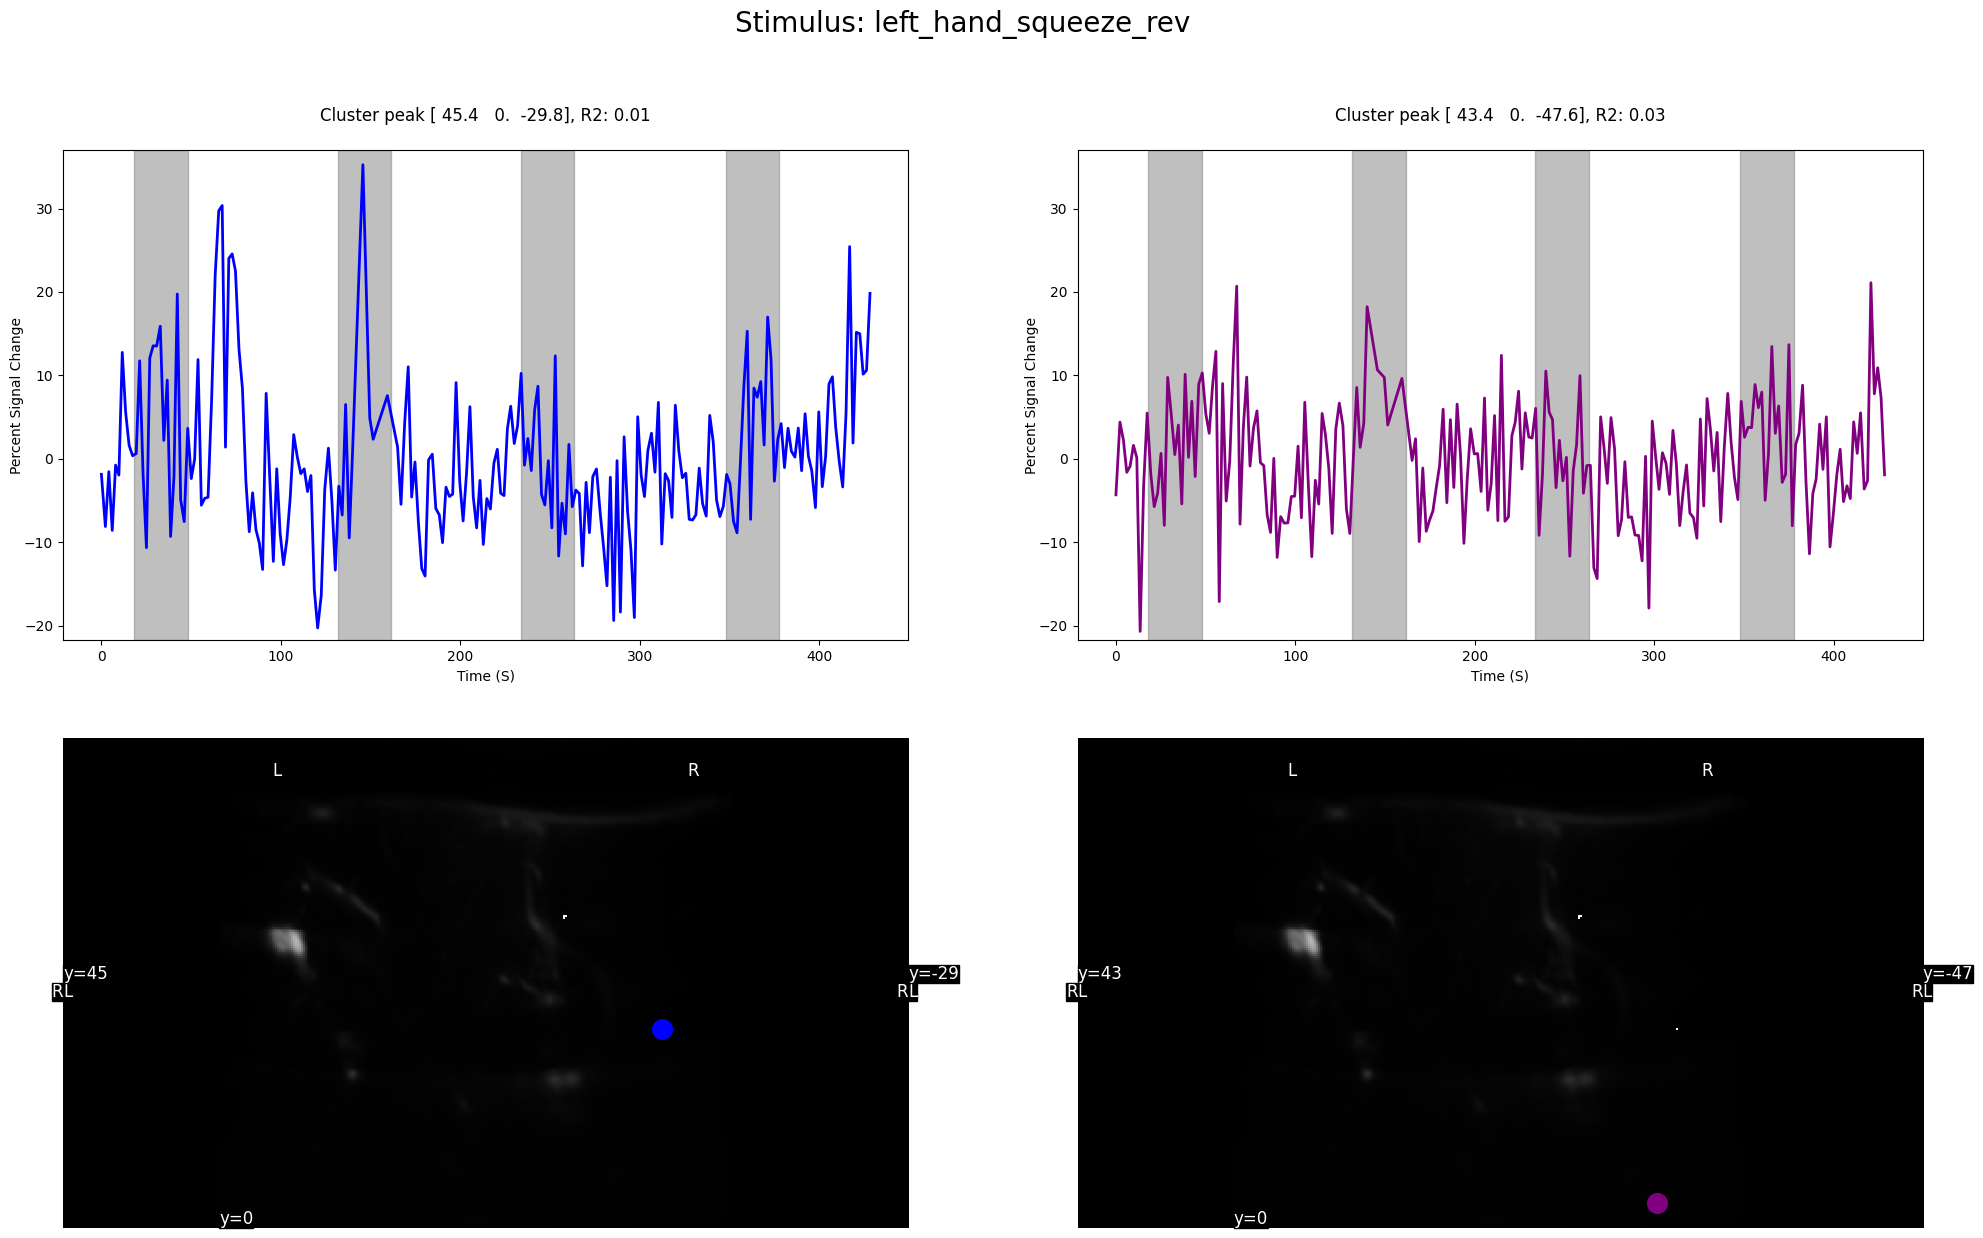

In [94]:
param_glm["standardize"] = "psc"
param_glm["t_r"] = 2.58

output_file = glm_plot_dir / f"{design_matrix_name}_{contrast_id}_time_series.png"

get_ROI_activation(nifti_data, fmri_glm, design_matrix, basic_contrasts, time_stamp, task_events, param_glm, output_file)

Processing contrast: left_hand_squeeze
Processing contrast: left_hand_squeeze_rev


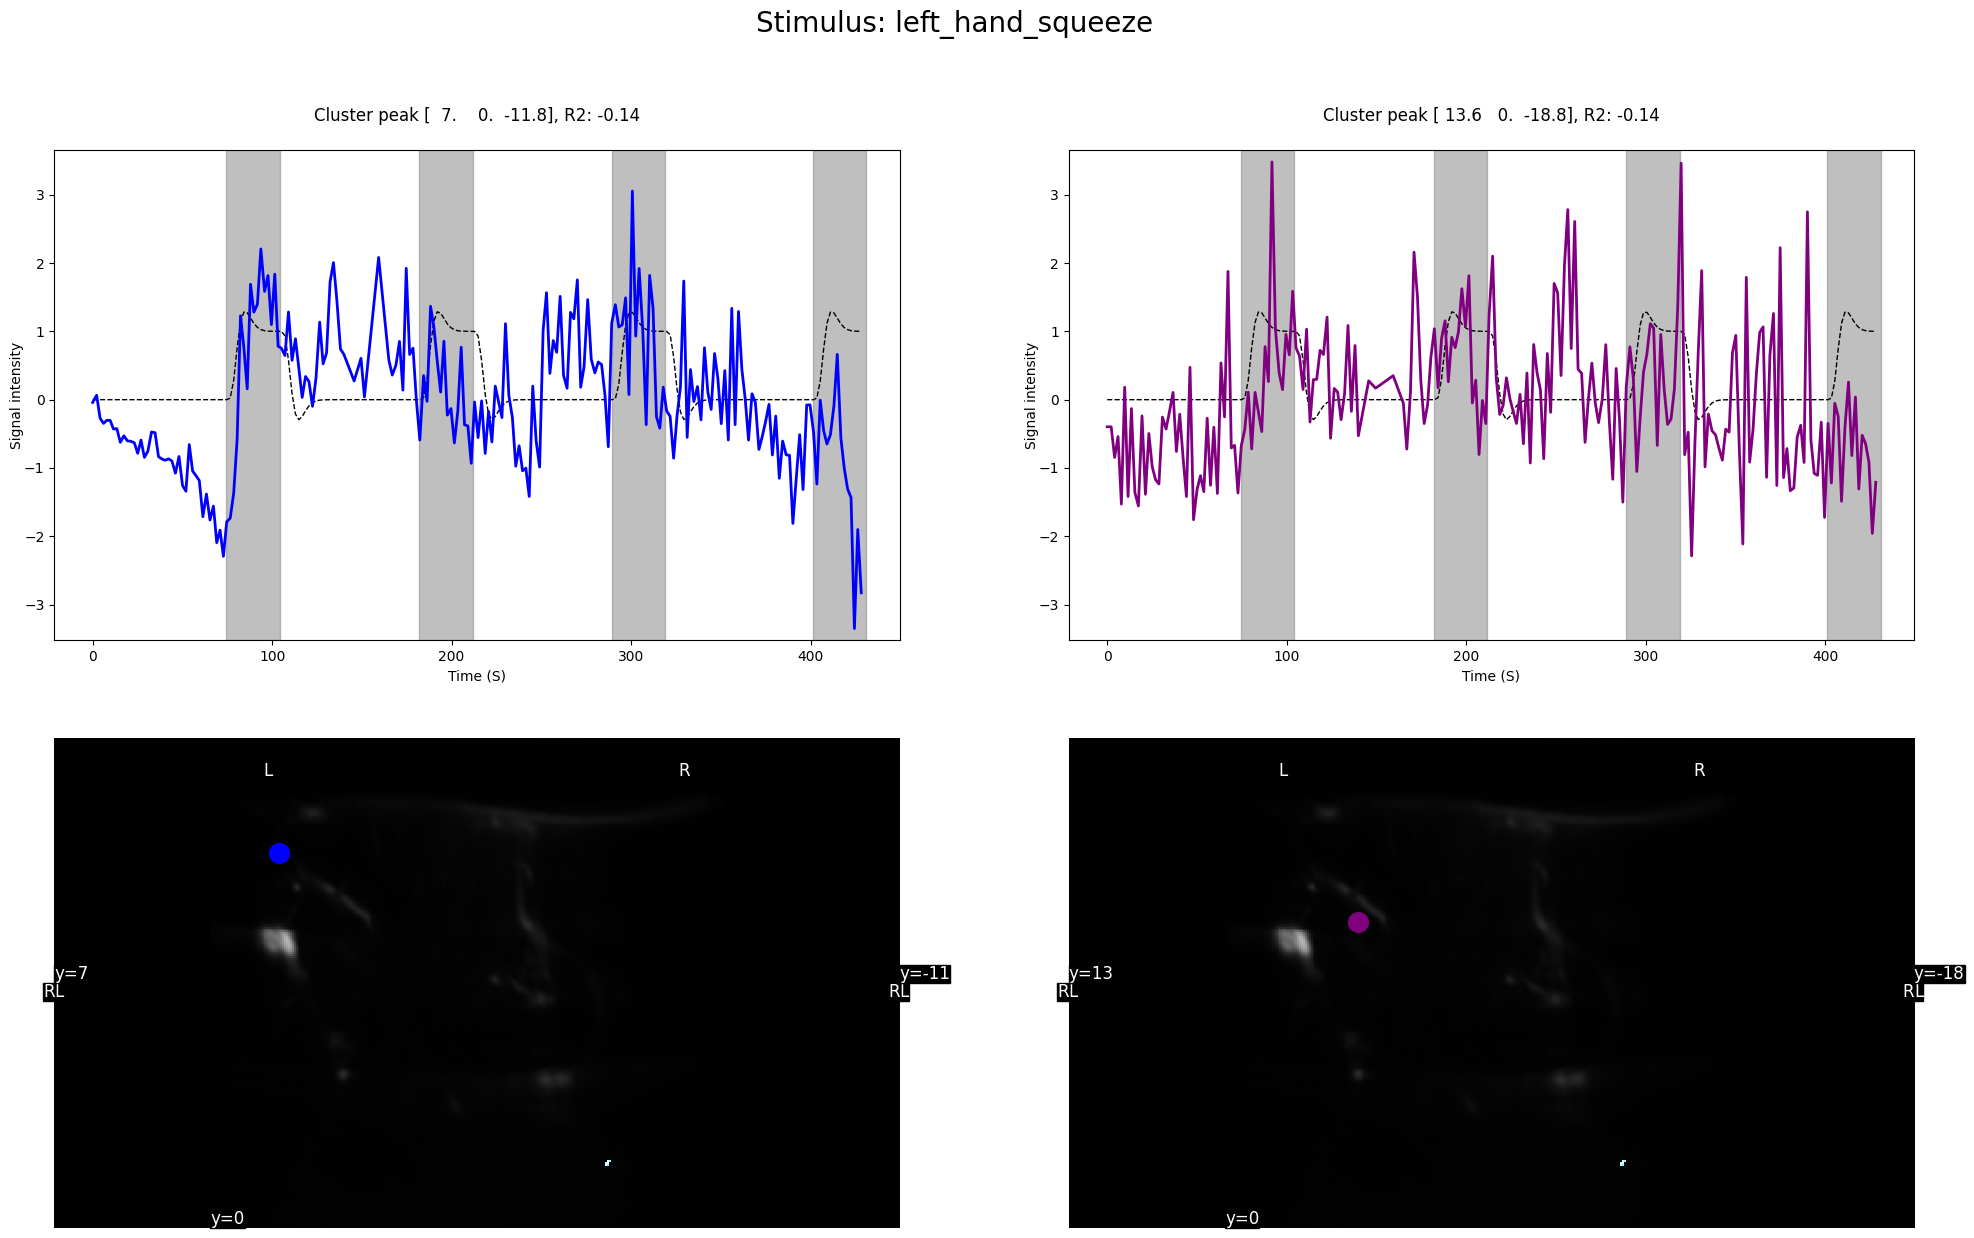

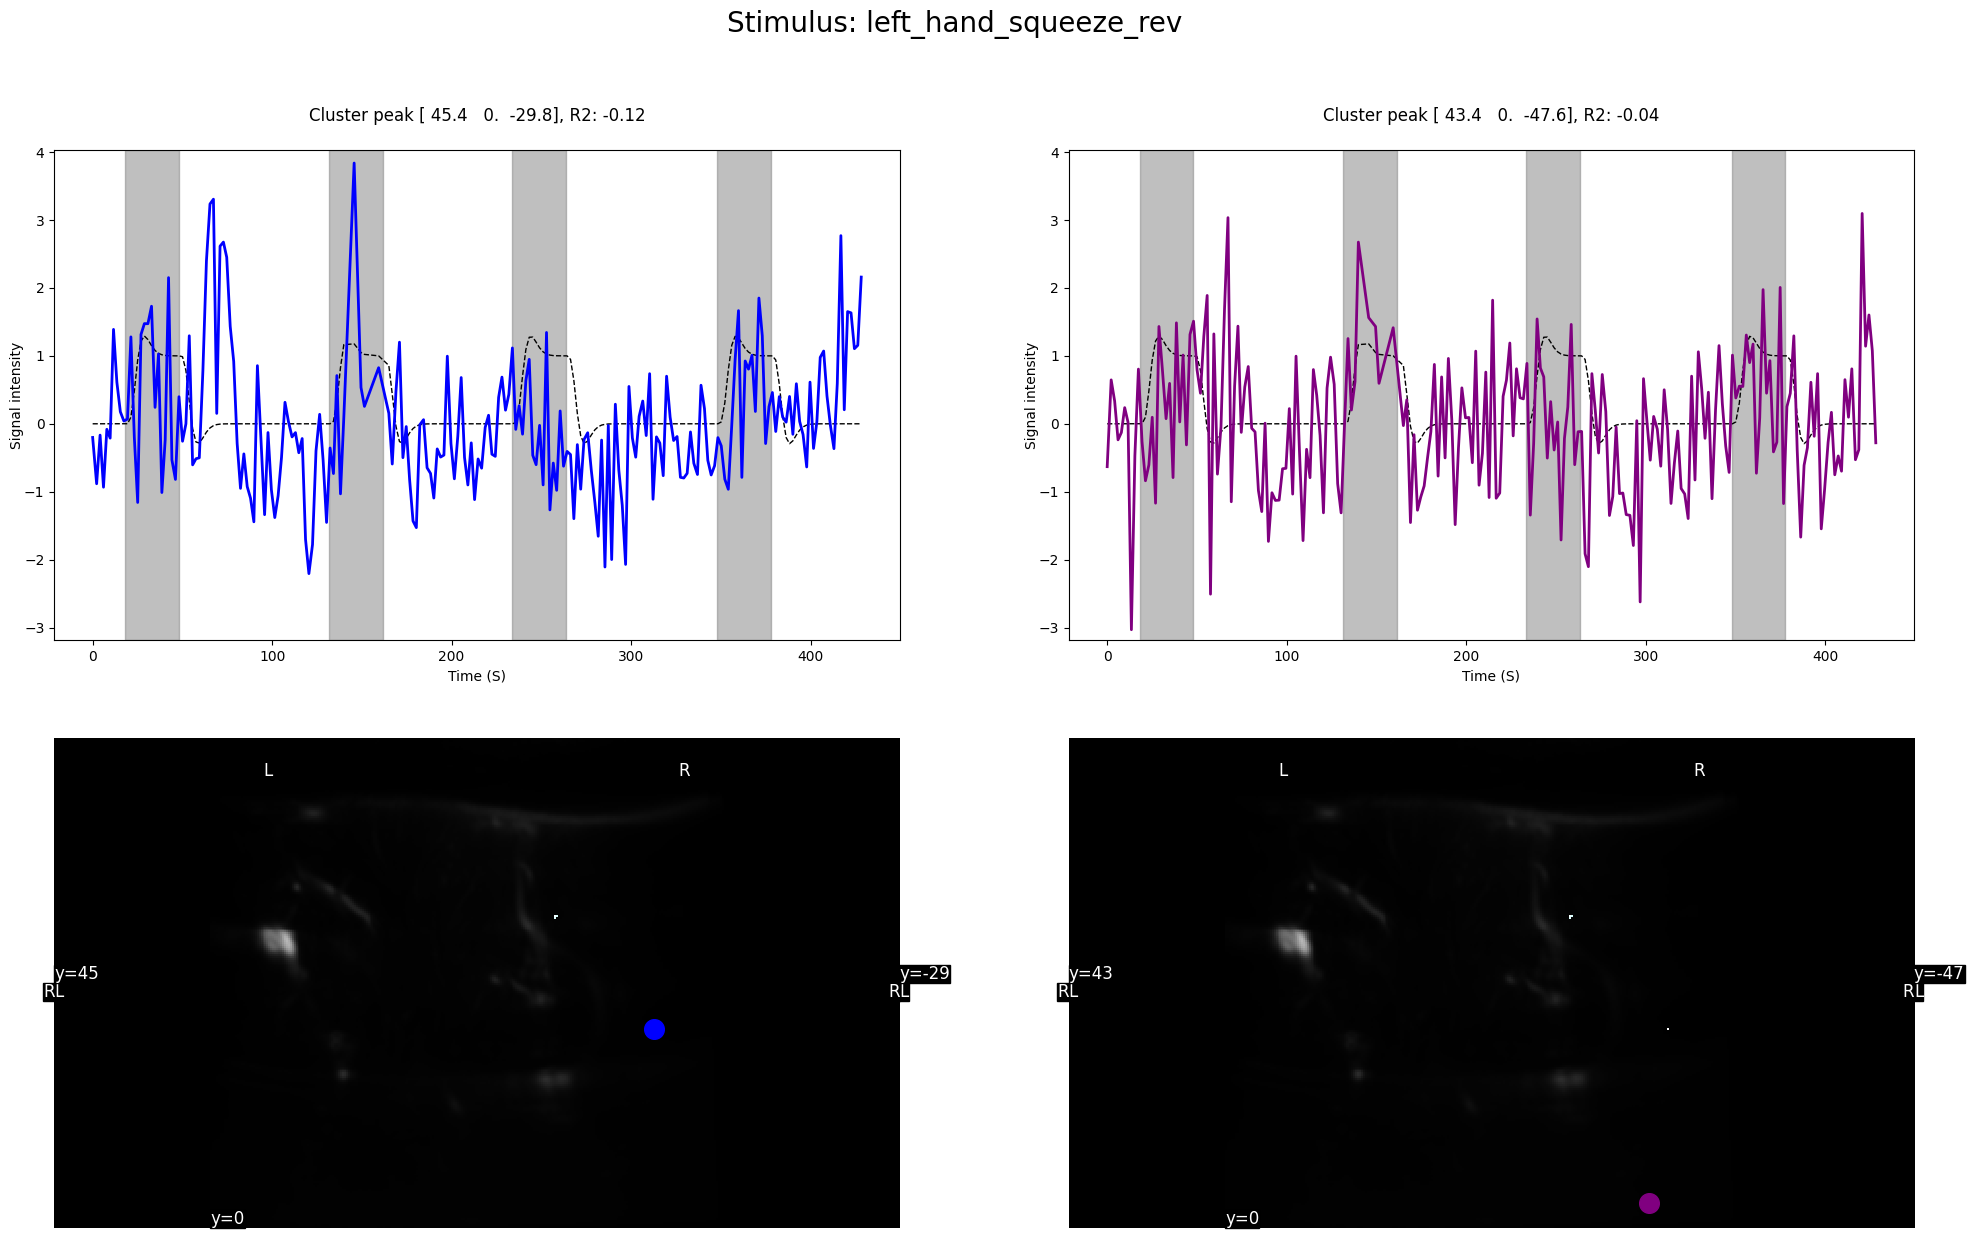

In [98]:
# zscore standardization
param_glm["standardize"] = "zscore"
param_glm["t_r"] = 3.5

output_file = glm_plot_dir / f"{design_matrix_name}_{contrast_id}_time_series_and_contrast_predicted.png"
get_ROI_activation(nifti_data, fmri_glm, design_matrix, basic_contrasts, time_stamp, task_events, param_glm, output_file)
